In [1]:
from PIL import Image
import numpy as np
from heat_experiment_2d import HeatExperiment2D
%matplotlib widget

In [2]:
im = Image.open(r"D:\Projects\Python\Palermo\2Dheat\vein_mask.bmp")
masks = ~np.array(im,dtype=bool)
src_val = 1
masks = src_val*masks

In [3]:
def fake_response_function(terminal_time, timestep):
    x = np.linspace(0, 0.5)
    y1 = 2*(1/(1+np.exp(-16*x))-0.5)
    x = np.linspace(-0.5, 0)
    y2 = -2*(1/(1+np.exp(-16*(x)))-0.5)
    y = np.append(y1, y2)
    x = np.linspace(0, 1, 100)
    
    t = np.arange(0, terminal_time, timestep)/terminal_time
    yt = np.interp(t, x, y)
    return yt

In [4]:
terminal = 80
timestep = 0.1
exp1 = HeatExperiment2D(terminal_time=terminal, timestep=timestep, vein_function_values = fake_response_function(terminal, timestep),
                        length_x=0.1, length_y=0.1, boundary_value=0, 
                        vein_masks = [masks], initial_value=0, cmap='cmr.arctic')



In [5]:
exp1.run_calculation()

In [6]:
exp1.solution

[array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 array([[7.20957177e-23, 2.04739214e-22, 5.09421958e-22, ...,
         1.03816853e-19, 4.03539255e-20, 1.38430759e-20],
        [1.46335586e-22, 4.15473277e-22, 1.03344666e-21, ...,
         2.02762994e-19, 7.88461429e-20, 2.70558354e-20],
        [2.25021683e-22, 6.38652757e-22, 1.58783432e-21, ...,
         2.92390699e-19, 1.13773680e-19, 3.90609362e-20],
        ...,
        [9.75123837e-12, 2.87218637e-11, 7.48928900e-11, ...,
         2.41394542e-28, 1.02876859e-28, 3.78953718e-29],
        [

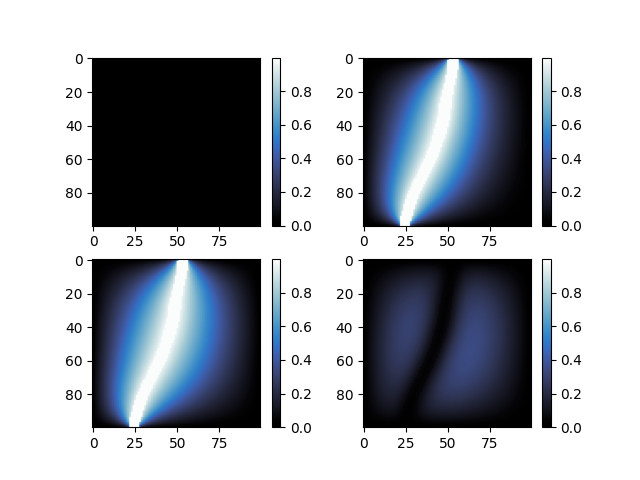

In [10]:
exp1.visualize_snapshots()

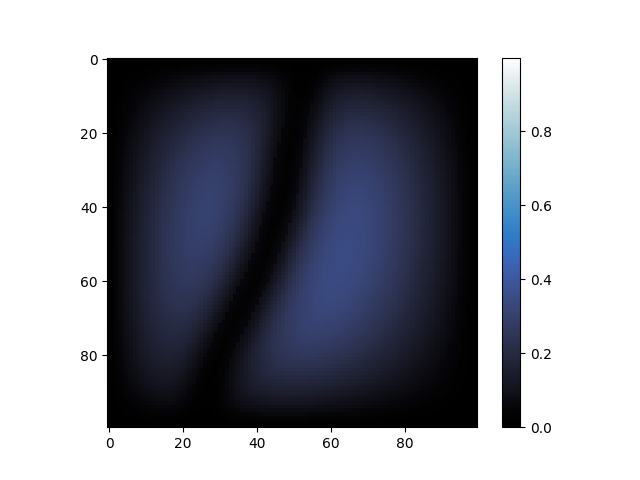

In [8]:
exp1.visualize_animated(save=True)